In [1]:
from collections.abc import Iterable
from dataclasses import dataclass
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.datasets.datasets import compact_regular_season_results_per_gender, compact_tourney_results_per_gender
from src.features import EloConfig, RunConfig, calculate_elo
from src.utils import Columns, Gender, get_data_directory

In [17]:
@dataclass
class NbEloConfig:
    base: float = 1000.0  # baseline Elo (set to 400 as requested)
    K: float = 20.0  # update factor
    carry: float = 0.75  # fraction of previous season deviation from base to carry over [0..1]
    use_margin: bool = True  # placeholder if you later add margin-based K scaling

In [18]:
@dataclass
class NbRunConfig:
    gender: Gender
    max_regular_season: int | None = None
    min_regular_season: int | None = None

In [19]:
def _expected_score(elo_a: float, elo_b: float) -> float:
    return 1.0 / (1.0 + 10 ** ((elo_b - elo_a) / 400.0))


def initialize_elos(teams: Iterable[int], base: float) -> dict[int, float]:
    return {int(t): base for t in teams}


def season_carryover(prev_elos: dict[int, float], cfg: EloConfig) -> dict[int, float]:
    next_elos = {}
    for tid, elo in prev_elos.items():
        next_elos[tid] = cfg.carry * elo + (1.0 - cfg.carry) * cfg.base
    return next_elos

In [5]:
def run_elo(rcfg: RunConfig, ecfg: EloConfig) -> tuple[pd.DataFrame, dict[int, float]]:
    df_regular = compact_regular_season_results_per_gender(rcfg.gender)
    df_tourney = compact_tourney_results_per_gender(rcfg.gender)

    if rcfg.min_regular_season is not None:
        df_regular = df_regular[df_regular["Season"] >= rcfg.min_regular_season]
        df_tourney = df_tourney[df_tourney["Season"] >= rcfg.min_regular_season]
    if rcfg.max_regular_season is not None:
        df_regular = df_regular[df_regular["Season"] <= rcfg.max_regular_season]
        df_tourney = df_tourney[df_tourney["Season"] < rcfg.max_regular_season]
    else:
        df_tourney = df_tourney[df_tourney["Season"] < df_regular["Season"].max()]

    df = pd.concat([df_regular, df_tourney], ignore_index=True)

    req_cols = {Columns.SEASON, Columns.DAY_NUM, Columns.WTEAM_ID, Columns.LTEAM_ID}
    missing = req_cols - set(df.columns)
    if missing:
        raise ValueError(f"df missing required columns: {missing}")

    work = df.sort_values([Columns.SEASON, Columns.DAY_NUM]).reset_index(drop=True).copy()

    teams = pd.Index(np.unique(work[[Columns.WTEAM_ID, Columns.LTEAM_ID]].values)).astype(int).tolist()
    elos: dict[int, float] = initialize_elos(teams, ecfg.base)

    seasons = work[Columns.SEASON].unique().tolist()
    preds = []
    w_elos = []
    l_elos = []

    cur_season = seasons[0]
    for _, row in work.iterrows():
        season = int(row.Season)
        if season != cur_season:
            elos = season_carryover(elos, ecfg)
            cur_season = season

        w, l = int(row.WTeamID), int(row.LTeamID)
        loc = str(row.WLoc) if "WLoc" in work.columns and pd.notna(row.WLoc) else None

        w_elo, l_elo = elos.get(w, ecfg.base), elos.get(l, ecfg.base)
        p_win = _expected_score(w_elo, l_elo)
        preds.append(p_win)
        w_elos.append(w_elo)
        l_elos.append(l_elo)

        k = ecfg.K
        if ecfg.use_margin and {Columns.WSCORE, Columns.LSCORE}.issubset(work.columns):
            margin = max(1, int(row.WScore) - int(row.LScore))
            mov_mult = np.log(margin + 1.0)
            k = ecfg.K * mov_mult

        elos[w] = w_elo + k * (1.0 - p_win)
        elos[l] = l_elo + k * (0.0 - (1.0 - p_win))

    work[Columns.PRED] = preds
    work[Columns.WELO] = w_elos
    work[Columns.LELO] = l_elos
    return work, elos

In [20]:
def log_loss_from_winprob(df_with_pred: pd.DataFrame) -> float:
    eps = 1e-15
    p = np.clip(df_with_pred[Columns.PRED].values, eps, 1 - eps)
    return float(-np.mean(np.log(p)))


def brier_from_winprob(df_with_pred: pd.DataFrame) -> float:
    p = df_with_pred[Columns.PRED].values
    y = np.ones_like(p)
    return float(np.mean((p - y) ** 2))


def evaluate_params(
    rcfg: RunConfig, carry: float, base: float = 400.0, K: float = 30.0, use_margin: bool = False
) -> dict[str, float]:
    cfg = EloConfig(base=base, K=K, carry=carry, use_margin=use_margin)
    scored_df, _ = run_elo(rcfg, cfg)
    return {"logloss": log_loss_from_winprob(scored_df), "brier": brier_from_winprob(scored_df)}


def grid_search_params(
    rcfg: RunConfig,
    carries: Iterable[float] = np.linspace(0.0, 1.0, 5),
    base: Iterable[float] = np.linspace(400, 2000, 3),
    K: Iterable[float] = np.linspace(10, 100, 3),
    use_margin: Iterable[bool] = (False,),
) -> pd.DataFrame:
    results = []
    for c, b, k, m in product(carries, base, K, use_margin):
        score = evaluate_params(rcfg, carry=float(c), base=b, K=k, use_margin=m)
        results.append(
            {
                "carry": float(c),
                "base": b,
                "k": k,
                "use_margin": m,
                "logloss": score["logloss"],
                "brier": score["brier"],
            }
        )

    out = pd.DataFrame(results).sort_values(["brier", "logloss"]).reset_index(drop=True)
    out["rank"] = np.arange(1, len(out) + 1)
    return out

In [7]:
elo_cfg = EloConfig(base=1000, carry=0.75, K=20, use_margin=True)
run_cfg = RunConfig(gender=Gender.MEN)
scored, final_elos = run_elo(run_cfg, elo_cfg)

print("Max ELO: ", max(final_elos.items(), key=lambda x: x[1]))
print("Min ELO: ", min(final_elos.items(), key=lambda x: x[1]))

Max ELO:  (1222, np.float64(1600.1252523243738))
Min ELO:  (1290, np.float64(394.0170107820672))


In [8]:
scored.tail()

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,Pred,WElo,LElo
195443,2025,132,1196,86,1397,77,N,0,0.586301,1549.635615,1489.061434
195444,2025,132,1272,84,1412,72,N,0,0.710600,1373.032393,1216.981726
195445,2025,132,1276,59,1458,53,N,0,0.366686,1319.840050,1414.769908
195446,2025,132,1433,68,1206,63,N,0,0.642972,1389.188752,1286.992925
195447,2025,132,1463,90,1165,84,N,0,0.687182,1269.306335,1132.594214


In [9]:
print("Log Loss: ", log_loss_from_winprob(scored))
print("Brier Score: ", brier_from_winprob(scored))

Log Loss:  0.5613965212248603
Brier Score:  0.19113660098271215


In [10]:
def plot_elo_distribution(final_elos: dict[int, float]) -> None:
    elos = pd.Series(final_elos, name="Elo")

    plt.figure(figsize=(8, 5))
    sns.histplot(elos, bins=30, kde=True, color="skyblue", edgecolor="black")

    plt.title("Distribution of Final Elo Ratings", fontsize=14)
    plt.xlabel("Elo Rating", fontsize=12)
    plt.ylabel("Number of Teams", fontsize=12)
    plt.grid(alpha=0.2)
    plt.show()

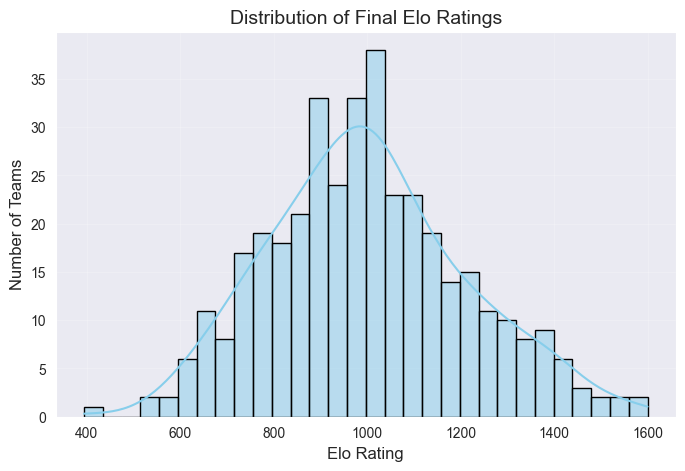

In [11]:
plot_elo_distribution(final_elos)

In [12]:
run_cfg = RunConfig(Gender.MEN, max_regular_season=2024)

search = grid_search_params(run_cfg, carries=[0.75], base=[1000], K=[20], use_margin=[True])

In [13]:
search

,carry,base,k,use_margin,logloss,brier,rank
0,0.75,1000,20,True,0.561266,0.191071,1


In [14]:
run_cfg = RunConfig(Gender.WOMEN, max_regular_season=2024)

search = grid_search_params(run_cfg, carries=[0.75], base=[1000], K=[20], use_margin=[True])

In [15]:
search

,carry,base,k,use_margin,logloss,brier,rank
0,0.75,1000,20,True,0.518504,0.173506,1


In [21]:
elo_cfg = EloConfig()
run_cfg = RunConfig(gender=Gender.BOTH, max_regular_season=2024)
scored, final_elos = calculate_elo(run_cfg, elo_cfg, include_predictions=True)

print("Max ELO: ", max(final_elos.items(), key=lambda x: x[1]))
print("Min ELO: ", min(final_elos.items(), key=lambda x: x[1]))

Max ELO:  (3376, np.float64(1766.2061402194809))
Min ELO:  (3354, np.float64(467.4238778950335))


In [22]:
print("Log Loss: ", log_loss_from_winprob(scored))
print("Brier Score: ", brier_from_winprob(scored))

Log Loss:  0.5436308768275437
Brier Score:  0.1838270164679564


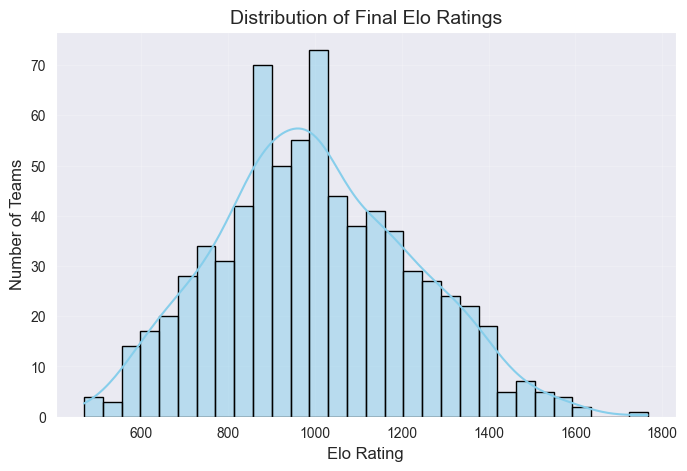

In [23]:
plot_elo_distribution(final_elos)

In [4]:
elo_cfg = EloConfig()
run_cfg = RunConfig(gender=Gender.MEN)
scored, final_elos = calculate_elo(run_cfg, elo_cfg)
scored.to_csv(get_data_directory() / "MOverallCompactResultsWithELO.csv", index=False)

In [5]:
elo_cfg = EloConfig()
run_cfg = RunConfig(gender=Gender.WOMEN)
scored, final_elos = calculate_elo(run_cfg, elo_cfg)
scored.to_csv(get_data_directory() / "WOverallCompactResultsWithELO.csv", index=False)